**Инициализация**

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [ ]:
import os
import pickle
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import boto3
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import scipy.sparse
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from implicit.als import AlternatingLeastSquares
import sklearn.metrics
from catboost import CatBoostClassifier, Pool
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("data_ref")
TRACKS_PATH = DATA_DIR / "tracks.parquet"
CATALOG_NAMES_PATH = DATA_DIR / "catalog_names.parquet"
INTERACTIONS_PATH = DATA_DIR / "interactions.parquet"

OUTPUT_DIR = Path("recsys_ref/data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RECOMMENDATIONS_DIR = Path("recsys_ref/recommendations")
RECOMMENDATIONS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DEBUG = True
DEBUG_ROWS_SUBSET = 50_000
PROD_ROWS_SUBSET = 10_000_000

In [ ]:
from concurrent.futures import ThreadPoolExecutor

# --- Reusable helpers for data prep, candidate prep and evaluation ---
def split_catalog_by_type(catalog_names, valid_types=("track", "album", "artist", "genre")):
    """Split `catalog_names` into type-specific DataFrames for reusable joins."""
    catalog_by_type = {}
    for cat_type in valid_types:
        catalog_by_type[cat_type] = catalog_names[catalog_names["type"] == cat_type].copy()
    return catalog_by_type



def prepare_exploded_relation(tracks, relation_col):
    """Prepare exploded track-relation pairs with numeric ids only."""
    exploded = tracks[["track_id", relation_col]].explode(relation_col).dropna(subset=[relation_col]).copy()
    exploded[relation_col] = pd.to_numeric(exploded[relation_col], errors="coerce")
    exploded = exploded.dropna(subset=[relation_col]).copy()
    exploded[relation_col] = exploded[relation_col].astype("int64")
    return exploded


def filter_relations_with_catalog(exploded_relation, catalog_ref, relation_col):
    """Keep only relation ids present in catalog and count broken links."""
    merged = exploded_relation.merge(
        catalog_ref[["id", "name"]],
        left_on=relation_col,
        right_on="id",
        how="left",
    )
    n_broken = int(merged["name"].isna().sum())
    valid_relations = merged.dropna(subset=["name"])[["track_id", relation_col]].drop_duplicates().copy()
    return valid_relations, n_broken


def filter_catalog_by_available_ids(catalog_df, valid_relations, relation_col):
    """Restrict catalog dimension to ids that remain after relation filtering."""
    valid_ids = valid_relations[[relation_col]].drop_duplicates().rename(columns={relation_col: "id"})
    return catalog_df.merge(valid_ids, on="id", how="inner")


def rebuild_track_relation_column(tracks, valid_relations, relation_col):
    """Rebuild relation list column from validated track-relation pairs."""
    relation_lists = (
        valid_relations.groupby("track_id", as_index=False)[relation_col]
        .agg(list)
        .rename(columns={relation_col: f"{relation_col}_clean"})
    )
    rebuilt = tracks.drop(columns=[relation_col]).merge(relation_lists, on="track_id", how="left")
    rebuilt[relation_col] = rebuilt[f"{relation_col}_clean"].map(
        lambda x: x if isinstance(x, list) else []
    )
    return rebuilt.drop(columns=[f"{relation_col}_clean"])


def normalize_track_relations(tracks, catalog_by_type, relation_specs):
    """Normalize list relations in `tracks` and return validated relation tables and stats.

    Stages per relation:
    1) prepare exploded relation table
    2) filter by available catalog ids
    3) compute broken-link counts
    4) clean track relation lists and catalog dimensions
    """
    tracks = tracks.copy()
    exploded_by_col = {}
    n_broken_by_col = {}

    for ref_type, col in relation_specs:
        exploded = prepare_exploded_relation(tracks, col)
        valid_relations, n_broken = filter_relations_with_catalog(
            exploded,
            catalog_by_type[ref_type],
            col,
        )

        exploded_by_col[col] = valid_relations
        n_broken_by_col[col] = n_broken
        catalog_by_type[ref_type] = filter_catalog_by_available_ids(
            catalog_by_type[ref_type],
            valid_relations,
            col,
        )
        tracks = rebuild_track_relation_column(tracks, valid_relations, col)

    return tracks, catalog_by_type, exploded_by_col, n_broken_by_col


def build_track_name_lookup(catalog_track_df):
    track_names = (
        catalog_track_df[["id", "name"]]
        .rename(columns={"id": "track_id", "name": "track_name"})
        .copy()
    )
    track_name_map = track_names.set_index("track_id")["track_name"].to_dict()
    return track_names, track_name_map



def count_broken_interaction_track_links(interactions, tracks):
    """Count interaction rows whose `track_id` is missing in tracks."""
    merged_inter = interactions.merge(
        tracks[["track_id"]].assign(_linked=1),
        on="track_id",
        how="left",
    )
    return int(merged_inter["_linked"].isna().sum())


def summarize_relation_broken_links(n_broken_by_col, relation_specs):
    """Print broken-link statistics for each track relation column."""
    for ref_type, col in relation_specs:
        if col in n_broken_by_col:
            print(
                f"Tracks {col} ids not in catalog_names (type={ref_type}, join):",
                f"{n_broken_by_col[col]} rows",
            )


def summarize_interaction_datetime_stats(interactions):
    """Print datetime range and NA share for `started_at` if present."""
    if "started_at" not in interactions.columns:
        return
    started = interactions["started_at"]
    print("interactions.started_at range:", started.min(), "->", started.max())
    print(
        "started_at NA count:",
        started.isna().sum(),
        f"({started.isna().mean():.4%})",
    )


def validate_reference_links(interactions, tracks, n_broken_by_col):
    """Validate cross-table links and print data-quality diagnostics."""
    n_inter_broken = count_broken_interaction_track_links(interactions, tracks)
    print(
        "Interactions with track_id not in tracks (join):",
        n_inter_broken,
        f"({n_inter_broken/len(interactions):.4%})",
    )
    summarize_relation_broken_links(
        n_broken_by_col,
        relation_specs=[("artist", "artists"), ("album", "albums"), ("genre", "genres")],
    )
    summarize_interaction_datetime_stats(interactions)



def prepare_items_events(tracks, interactions, track_names):
    items = tracks.merge(track_names, on="track_id", how="left")
    events = interactions.sort_values(["user_id", "started_at"]).reset_index(drop=True)

    user_encoder = LabelEncoder()
    item_encoder = LabelEncoder()
    user_encoder.fit(events["user_id"])
    item_encoder.fit(events["track_id"])

    events["user_id_enc"] = user_encoder.transform(events["user_id"])
    events["track_id_enc"] = item_encoder.transform(events["track_id"])
    items["track_id_enc"] = item_encoder.transform(items["track_id"])
    return items, events, user_encoder, item_encoder


def prepare_user_features(train_events, ref_date):
    user_activity = train_events.groupby("user_id").size().reset_index(name="user_activity")
    user_last_started = train_events.groupby("user_id")["started_at"].max().reset_index(name="user_last_started_at")
    user_last_started["days_since_last_user_interaction"] = (
        ref_date - pd.to_datetime(user_last_started["user_last_started_at"])
    ).dt.days

    user_features = user_activity.merge(
        user_last_started[["user_id", "days_since_last_user_interaction"]],
        on="user_id",
    )
    days_since_median = float(user_features["days_since_last_user_interaction"].median())
    return user_features, days_since_median


def prepare_candidate_labels(candidates, events_train_candidates, random_state=42, neg_per_user=4):
    events_labels_target = (
        events_train_candidates[["user_id", "track_id"]]
        .drop_duplicates()
        .rename(columns={"track_id": "item_id"})
    )
    events_labels_target["target"] = 1

    labeled = candidates.merge(events_labels_target, on=["user_id", "item_id"], how="left")
    labeled["target"] = labeled["target"].fillna(0).astype(int)

    candidates_to_sample = labeled.groupby("user_id").filter(lambda x: x["target"].sum() > 0)
    positives = candidates_to_sample.query("target == 1")
    negatives = (
        candidates_to_sample.query("target == 0")
        .groupby("user_id")
        .apply(lambda x: x.sample(min(neg_per_user, len(x)), random_state=random_state))
        .reset_index(drop=True)
    )
    candidates_for_train = pd.concat([positives, negatives], ignore_index=True)
    return labeled, candidates_for_train, positives, negatives


def generate_content_recommendations(train_events, items_content, track_genre_matrix, recommend_fn, top_n=100):
    user_seeds = (
        train_events.sort_values(by=["user_id", "track_seq"], ascending=[True, False])
        .drop_duplicates(subset=["user_id"], keep="first")[["user_id", "track_id"]]
        .rename(columns={"track_id": "seed_track"})
    )
    seed_tracks = user_seeds["seed_track"].drop_duplicates().values

    def _seed_track_to_rows(seed_t):
        recs = recommend_fn(seed_t, items_content, track_genre_matrix, k=top_n)
        if recs.empty:
            return []
        return [
            {"seed_track": seed_t, "rank": r, "item_id": row.track_id, "score": row.similarity}
            for r, row in enumerate(recs.itertuples(index=False), 1)
        ]

    with ThreadPoolExecutor(max_workers=os.cpu_count() or 4) as executor:
        seed_recs_nested = list(
            tqdm(
                executor.map(_seed_track_to_rows, seed_tracks),
                total=len(seed_tracks),
                desc="Content recs",
            )
        )

    seed_recs = [row for rows in seed_recs_nested for row in rows]
    if len(seed_recs) == 0:
        return pd.DataFrame(columns=["user_id", "item_id", "score", "rank"]), user_seeds

    seed_recs_df = pd.DataFrame(seed_recs)
    content_recs = user_seeds.merge(seed_recs_df, on="seed_track")[["user_id", "item_id", "score", "rank"]]
    return content_recs, user_seeds


### **=== ЭТАП 1 ===**

**Загрузка первичных данных**

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [ ]:
tracks = pd.read_parquet(TRACKS_PATH)
catalog_names = pd.read_parquet(CATALOG_NAMES_PATH)
interactions = pd.read_parquet(INTERACTIONS_PATH)

# Subset data
rows_limit = DEBUG_ROWS_SUBSET if DEBUG else PROD_ROWS_SUBSET
interactions = interactions.sample(
    n=min(rows_limit, len(interactions)), random_state=RANDOM_STATE
)
track_ids = interactions["track_id"].unique()
tracks = tracks[tracks["track_id"].isin(track_ids)].copy()

# Split catalog
catalog_by_type = split_catalog_by_type(catalog_names)

# Normalize list relations once and reuse in EDA/modeling
tracks, catalog_by_type, exploded_by_col, n_broken_by_col = normalize_track_relations(
    tracks,
    catalog_by_type,
    relation_specs=[("artist", "artists"), ("album", "albums"), ("genre", "genres")],
)

catalog_by_type["track"] = catalog_by_type["track"][
    catalog_by_type["track"]["id"].isin(track_ids)
].copy()

catalog_track = catalog_by_type["track"]
catalog_album = catalog_by_type["album"]
catalog_artist = catalog_by_type["artist"]
catalog_genre = catalog_by_type["genre"]

catalog_names = pd.concat(
    [catalog_track, catalog_album, catalog_artist, catalog_genre],
    ignore_index=True,
)

track_names, track_name_map = build_track_name_lookup(catalog_track)
listened_track_ids = set(track_ids)
all_track_ids = set(tracks["track_id"].unique())

print(
    f"Subset: interactions={len(interactions)}, tracks={len(tracks)}, catalog_names={len(catalog_names)} (limit={rows_limit})"
)

print("tracks:", tracks.shape)
print("catalog_names:", catalog_names.shape)
print("interactions:", interactions.shape)

display(tracks.sample(5, random_state=RANDOM_STATE))
display(catalog_names.sample(5, random_state=RANDOM_STATE))
display(interactions.sample(5, random_state=RANDOM_STATE))


Subset: interactions=10000000, tracks=615112, catalog_names=1203019 (limit=10000000)
tracks: (615112, 4)
catalog_names: (1203019, 3)
interactions: (10000000, 4)


,track_id,albums,artists,genres
844083,67850024,[11183751],[8555640],"[3, 75]"
512765,35545738,[4437956],"[4917713, 5132482]","[68, 1197]"
890998,73742776,"[12832128, 14016605]",[615],[11]
567851,39059739,[5025171],[5494678],[13]
861741,70079151,"[11807598, 11890338, 12623421, 16478885]",[6856],[11]


,id,type,name
1013482,50932023,track,Орёл
1197805,96543229,track,Manticore
47404,414712,album,Animositisomina
298709,7459072,album,VKRUG 2
1177342,87157892,track,Be Tender with Me Baby


,user_id,track_id,track_seq,started_at
117,337107,545860,118,2022-06-17
377,706479,33485639,378,2022-09-09
30,1345956,76275,31,2022-03-29
292,665264,83396540,293,2022-11-02
233,1300025,44610707,234,2022-08-20


### **Обзор данных**

Проверяем данные, есть ли с ними явные проблемы.

In [41]:
# Базовый обзор: типы, пропуски, уникальные значения
def df_overview(df: pd.DataFrame, name: str, id_cols=None):
    print(f"=== {name} ===")
    df.info()
    print()
    print("shape:", df.shape)
    print()
    na = df.isna().mean().sort_values(ascending=False)
    print("NA share (top-20):")
    display(na.head(20))
    if id_cols:
        n_combo = df[id_cols].drop_duplicates().shape[0]
        print(f"nunique({id_cols}) = {n_combo}")
    print()

df_overview(tracks, "tracks", id_cols=["track_id"])
df_overview(catalog_names, "catalog_names", id_cols=["id", "type"])
df_overview(interactions, "interactions", id_cols=["user_id", "track_id"])


=== tracks ===
<class 'pandas.core.frame.DataFrame'>
Index: 615112 entries, 1 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   track_id  615112 non-null  int64 
 1   albums    615112 non-null  object
 2   artists   615112 non-null  object
 3   genres    615112 non-null  object
dtypes: int64(1), object(3)
memory usage: 23.5+ MB

shape: (615112, 4)

NA share (top-20):


track_id    0.0
albums      0.0
artists     0.0
genres      0.0
dtype: float64

nunique(['track_id']) = 615112

=== catalog_names ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1203019 entries, 0 to 1203018
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   id      1203019 non-null  int64 
 1   type    1203019 non-null  object
 2   name    1203019 non-null  object
dtypes: int64(1), object(2)
memory usage: 27.5+ MB

shape: (1203019, 3)

NA share (top-20):


id      0.0
type    0.0
name    0.0
dtype: float64

nunique(['id', 'type']) = 1203019

=== interactions ===
<class 'pandas.core.frame.DataFrame'>
Index: 10000000 entries, 130 to 108
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 248.0 MB

shape: (10000000, 4)

NA share (top-20):


user_id       0.0
track_id      0.0
track_seq     0.0
started_at    0.0
dtype: float64

nunique(['user_id', 'track_id']) = 10000000



**Проверка связей между таблицами и диапазон дат**

Проверяем «битые» ссылки (interactions → tracks, tracks → catalog_names) и диапазон дат в `interactions.started_at`.

In [42]:
# Проверка связей между таблицами и диапазон дат
validate_reference_links(interactions, tracks, n_broken_by_col)


Interactions with track_id not in tracks (join): 0 (0.0000%)
Tracks artists ids not in catalog_names (type=artist, join): 0 rows
Tracks albums ids not in catalog_names (type=album, join): 0 rows
Tracks genres ids not in catalog_names (type=genre, join): 29747 rows
interactions.started_at range: 2022-01-01 00:00:00 -> 2022-12-31 00:00:00
started_at NA count: 0 (0.0000%)


**Выводы**

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

### **=== ЭТАП 2 ===**

**EDA**

Распределение количества прослушанных треков.

count    1.121447e+06
mean     8.917051e+00
std      1.729086e+01
min      1.000000e+00
50%      4.000000e+00
90%      2.100000e+01
95%      3.400000e+01
99%      7.900000e+01
max      7.440000e+02
Name: n_events, dtype: float64

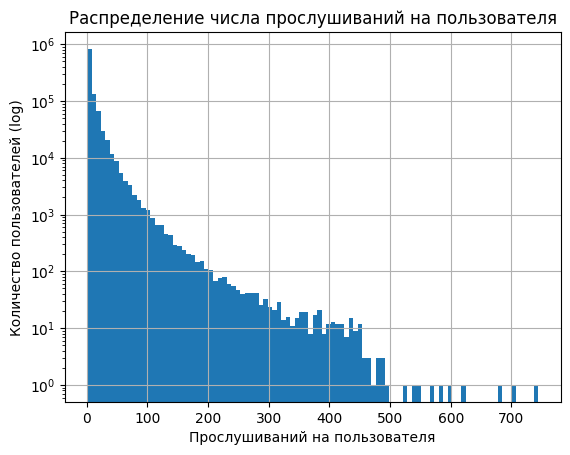

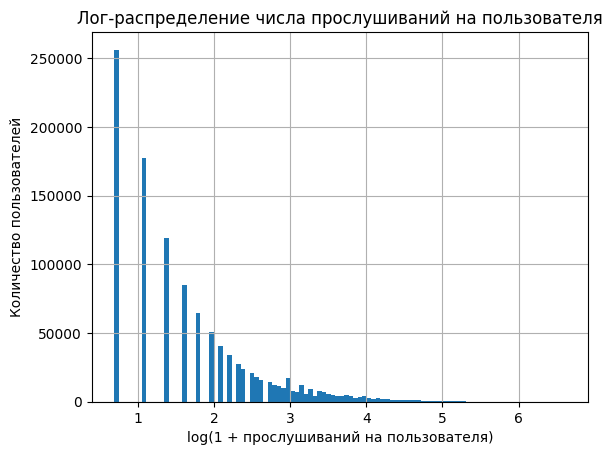

In [43]:
# Распределение количества прослушиваний (интеракций) на пользователя
user_cnt = (
    interactions.groupby("user_id")["track_id"].size().rename("n_events")
)
display(user_cnt.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure()
user_cnt.hist(bins=100)
plt.yscale("log")
plt.xlabel("Прослушиваний на пользователя")
plt.ylabel("Количество пользователей (log)")
plt.title("Распределение числа прослушиваний на пользователя")
plt.show()

plt.figure()
np.log1p(user_cnt).hist(bins=100)
plt.xlabel("log(1 + прослушиваний на пользователя)")
plt.ylabel("Количество пользователей")
plt.title("Лог-распределение числа прослушиваний на пользователя")
plt.show()


Наиболее популярные треки

In [44]:
def top_by_events(
    interactions,
    catalog_by_type,
    *,
    item_col,
    catalog_type,
    explode_col=None,
    exploded_by_col=None,
    name_col=None,
    top_k=20,
    top_pct=0.01,
):
    """
    Топ сущностей по числу событий.
    """
    if explode_col is None:
        count_series = interactions.groupby(item_col).size().sort_values(ascending=False)
        group_col = item_col
    else:
        exploded = interactions.merge(
            exploded_by_col[explode_col], on="track_id", how="left"
        ).dropna(subset=[explode_col])
        count_series = exploded.groupby(explode_col).size().sort_values(ascending=False)
        group_col = explode_col

    top = count_series.head(top_k).reset_index()
    top.columns = [group_col, "n_events"]

    catalog_ref = catalog_by_type[catalog_type][["id", "name"]]
    top = top.merge(
        catalog_ref.rename(columns={"id": group_col}),
        on=group_col,
        how="left",
    )
    out_name = name_col if name_col else f"{catalog_type}_name"
    top = top.rename(columns={"name": out_name})

    n_top = max(1, int(top_pct * len(count_series)))
    share = count_series.head(n_top).sum() / count_series.sum()
    return top, count_series, share


# Наиболее популярные треки
top_tracks, track_pop, share_top1pct = top_by_events(
    interactions,
    catalog_by_type,
    item_col="track_id",
    catalog_type="track",
    top_k=20,
    top_pct=0.01,
)
display(top_tracks)
print(f"Share of events covered by top 1% tracks: {share_top1pct:.2%}")


,track_id,n_events,track_name
0,53404,4834,Smells Like Teen Spirit
1,33311009,4809,Believer
2,178529,4618,Numb
3,35505245,4451,I Got Love
4,65851540,4012,Юность
5,60292250,3917,Blinding Lights
6,51241318,3870,In The End
7,795836,3830,Shape Of My Heart
8,32947997,3813,Shape of You
9,24692821,3768,Way Down We Go


Share of events covered by top 1% tracks: 36.11%


Наиболее популярные жанры

In [45]:
top_genres, genre_pop, share_top1pct_genres = top_by_events(
    interactions,
    catalog_by_type,
    item_col="genres",
    catalog_type="genre",
    explode_col="genres",
    exploded_by_col=exploded_by_col,
    name_col="genre_name",
    top_k=20,
    top_pct=0.01,
)
display(top_genres)
print(
    f"Share of events covered by top 1% genres: {share_top1pct_genres:.2%}"
)


,genres,n_events,genre_name
0,11.0,2497774,pop
1,75.0,1697153,rap
2,102.0,1395913,allrock
3,20.0,1198031,ruspop
4,3.0,1135203,rusrap
5,68.0,902233,electronics
6,16.0,731271,dance
7,2.0,590960,rusrock
8,14.0,573393,rock
9,47.0,560232,metal


Share of events covered by top 1% genres: 15.06%


Треки, которые никто не прослушал

In [46]:
never_listened = sorted(list(all_track_ids - listened_track_ids))

print(
    "Tracks never listened:",
    len(never_listened),
    f"({len(never_listened)/len(all_track_ids):.2%} of catalog tracks)",
)

display(
    pd.DataFrame({
        "track_id": never_listened[:20],
        "track_name": [track_name_map.get(t) for t in never_listened[:20]],
    })
)

Tracks never listened: 0 (0.00% of catalog tracks)


,track_id,track_name


### **Преобразование данных**

In [47]:
items, events, user_encoder, item_encoder = prepare_items_events(
    tracks,
    interactions,
    track_names,
)

print("items:", items.shape)
print("events:", events.shape)
display(items.head())
display(events.head())


items: (615112, 6)
events: (10000000, 6)


,track_id,albums,artists,genres,track_name,track_id_enc
0,38,"[3, 2490753]",[16],"[11, 21]",Momma's Boy,0
1,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],Don't Upset The Rhythm (Go Baby Go),1
2,141,"[12, 214, 60093, 2490809, 10023160, 15635235, ...",[84],[11],Never Forget You,2
3,143,"[12, 214, 2490809]",[84],[11],Every Now And Then,3
4,144,"[13, 99422]",[90],"[59, 102]",Leave Me,4


,user_id,track_id,track_seq,started_at,user_id_enc,track_id_enc
0,0,1750835,9,2022-07-30,0,72292
1,0,18102829,24,2022-09-13,0,175019
2,1,108208,2,2022-06-13,1,12263
3,1,628687,5,2022-06-15,1,42037
4,3,27317251,6,2022-03-18,2,244904


### **Сохранение данных**

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [48]:
# Сохранение данных (локально) + (опционально) в S3
load_dotenv()
s3_bucket = os.environ.get("S3_BUCKET_NAME")
s3_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
s3_secret_access_key = os.environ.get("AWS_SECRET_ACCESS_KEY")

items_out = OUTPUT_DIR / "items.parquet"
events_out = OUTPUT_DIR / "events.parquet"

items.to_parquet(items_out, index=False)
events.to_parquet(events_out, index=False)

encoders_path = OUTPUT_DIR / "encoders.pkl"
with open(encoders_path, "wb") as f:
    pickle.dump({"user_encoder": user_encoder, "item_encoder": item_encoder}, f)

print("Saved locally:")
print(" -", items_out.resolve())
print(" -", events_out.resolve())

# if s3_bucket and s3_access_key and s3_secret_access_key:
#     s3_prefix = "recsys/data"
#     client = boto3.client(
#         "s3",
#         aws_access_key_id=s3_access_key,
#         aws_secret_access_key=s3_secret_access_key,
#     )
#     client.upload_file(
#         str(items_out), s3_bucket, f"{s3_prefix}/items.parquet"
#     )
#     client.upload_file(
#         str(events_out), s3_bucket, f"{s3_prefix}/events.parquet"
#     )
#     print(f"Uploaded to s3://{s3_bucket}/{s3_prefix}/")
# else:
#     print(
#         "S3 creds not set (S3_BUCKET_NAME, AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY)"
#         " -> skip S3 upload"
#     )


Saved locally:
 - C:\Users\Selecty\Desktop\leroy\yandex-mle\mle-project-sprint-4-v001\recsys\data\items.parquet
 - C:\Users\Selecty\Desktop\leroy\yandex-mle\mle-project-sprint-4-v001\recsys\data\events.parquet


### **Очистка памяти**

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [49]:
# Очистка памяти: удаляем датафреймы этапов 1–2, данные для моделирования будут загружены из S3
del tracks, catalog_names, interactions, items, events
gc.collect()

26963

### **=== ЭТАП 3 ===**

**Загрузка данных**

Если необходимо, то загружаем items.parquet, events.parquet.

In [50]:
# Загрузка подготовленных данных
items_path = OUTPUT_DIR / "items.parquet"
events_path = OUTPUT_DIR / "events.parquet"

items = pd.read_parquet(items_path)
events = pd.read_parquet(events_path)

print("items:", items.shape)
print("events:", events.shape)
display(items.head())
display(events.head())


items: (615112, 6)
events: (10000000, 6)


,track_id,albums,artists,genres,track_name,track_id_enc
0,38,"[3, 2490753]",[16],"[11, 21]",Momma's Boy,0
1,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],Don't Upset The Rhythm (Go Baby Go),1
2,141,"[12, 214, 60093, 2490809, 10023160, 15635235, ...",[84],[11],Never Forget You,2
3,143,"[12, 214, 2490809]",[84],[11],Every Now And Then,3
4,144,"[13, 99422]",[90],"[59, 102]",Leave Me,4


,user_id,track_id,track_seq,started_at,user_id_enc,track_id_enc
0,0,1750835,9,2022-07-30,0,72292
1,0,18102829,24,2022-09-13,0,175019
2,1,108208,2,2022-06-13,1,12263
3,1,628687,5,2022-06-15,1,42037
4,3,27317251,6,2022-03-18,2,244904


### **Разбиение данных**

Разбиваем данные на тренировочную, тестовую выборки.

In [51]:
SPLIT_DATE = "2022-12-16"
train_events = events[events["started_at"] < SPLIT_DATE]
test_events = events[events["started_at"] >= SPLIT_DATE]
train_user_ids_set = set(train_events["user_id"])
print("train_events:", train_events.shape)
print("test_events:", test_events.shape)

train_events: (9375321, 6)
test_events: (624679, 6)


### **RecSys**

### **Топ популярных**

Рассчитаем рекомендации как топ популярных.

In [52]:
# Top Popular: robust popularity = reach (users) × engagement (track_seq)
# lower seq = stronger signal
TOP_N = 100

# Per-user max track_seq so engagement is relative to each user's history (early vs late)
max_seq_per_user = (
    train_events.groupby("user_id")["track_seq"].transform("max").clip(lower=1)
)
_train = train_events.assign(
    engagement=1.0 / (1.0 + train_events["track_seq"] / max_seq_per_user)
)

item_popularity = (
    _train.groupby("track_id")
    .agg(users=("user_id", "nunique"), avg_engagement=("engagement", "mean"))
    .reset_index()
    .rename(columns={"track_id": "item_id"})
)

# Scale
scaler = MinMaxScaler()
item_popularity[["users_norm", "avg_engagement_norm"]] = scaler.fit_transform(
    item_popularity[["users", "avg_engagement"]]
)
item_popularity["popularity_score"] = (
    item_popularity["users_norm"] * item_popularity["avg_engagement_norm"]
)
item_popularity = item_popularity.sort_values("popularity_score", ascending=False)

item_popularity_top = item_popularity.head(TOP_N)[['item_id', 'popularity_score']].rename(
    columns={'popularity_score': 'score'}
).reset_index(drop=True)

item_popularity_top.to_parquet(RECOMMENDATIONS_DIR / "cold_recs.parquet", index=False)
print(f"Saved cold_recs to parquet: {len(item_popularity_top)} rows")

Saved cold_recs to parquet: 100 rows


In [53]:
# Display TOPN cold_start recs
top_items_with_name = item_popularity.merge(
    items[["track_id", "track_name"]].rename(columns={"track_id": "item_id"}),
    on="item_id",
    how="left",
)

top_items_with_name = top_items_with_name[
    ["item_id", "track_name", "users", "avg_engagement", "popularity_score"]
]

with pd.option_context("display.max_rows", 10):
    display(top_items_with_name.head(10))

,item_id,track_name,users,avg_engagement,popularity_score
0,53404,Smells Like Teen Spirit,4788,0.916164,0.833133
1,178529,Numb,4570,0.874936,0.716413
2,37384,Zombie,3622,0.930400,0.651759
3,48951,It's My Life,3276,0.915838,0.569537
4,328683,Bring Me To Life,3267,0.860040,0.491760
5,148345,Californication,2984,0.878952,0.472741
6,137670,Gangsta's Paradise,2800,0.899209,0.467293
7,795836,Shape Of My Heart,3775,0.790764,0.458910
8,52100,Don't Speak,2603,0.913028,0.449441
9,10216,Wind Of Change,2313,0.952108,0.437135


### **Персональные**

Рассчитаем персональные рекомендации.

In [ ]:
# 3.2 Personal Recommendations (ALS)

# Prepare data for ALS: create user-item matrix
# Load encoders saved during data preparation (Stage 1)
encoders_path = OUTPUT_DIR / "encoders.pkl"
with open(encoders_path, "rb") as f:
    encoders = pickle.load(f)
user_encoder = encoders["user_encoder"]
item_encoder = encoders["item_encoder"]
unique_users = user_encoder.classes_
unique_items = item_encoder.classes_

# Add encoded columns for direct matrix construction
events_train = train_events.copy()
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_train["item_id_enc"] = item_encoder.transform(events_train["track_id"])
events_train["rating"] = 1.0  # Binary implicit feedback

# Create CSR matrix directly
user_item_matrix = scipy.sparse.csr_matrix(
    (
        events_train["rating"].values,
        (events_train["user_id_enc"].values, events_train["item_id_enc"].values),
    ),
    shape=(len(unique_users), len(unique_items)),
    dtype=np.float32,
)

print(f"User-item matrix shape: {user_item_matrix.shape}")
print(f"Non-zero entries: {user_item_matrix.nnz}")

# Train ALS model
als_model = AlternatingLeastSquares(
    factors=50,
    regularization=0.1,
    iterations=15,
    random_state=RANDOM_STATE,
    num_threads=4
)

print("Training ALS model...")
als_model.fit(user_item_matrix)
print("ALS model trained successfully")

# Generate recommendations for train users (candidates for CatBoost ranker)
train_users_recommend = train_events["user_id"].unique()
user_ids_encoded = user_encoder.transform(train_users_recommend)

item_ids_enc, als_scores = als_model.recommend(
    user_ids_encoded,
    user_item_matrix[user_ids_encoded],
    filter_already_liked_items=True,
    N=TOP_N
)

# Convert to DataFrame
als_recommendations = pd.DataFrame({
    "user_id_enc": user_ids_encoded,
    "item_id_enc": [row.tolist() for row in item_ids_enc],
    "score": [row.tolist() for row in als_scores],
})
als_recommendations = als_recommendations.explode(
    ["item_id_enc", "score"], ignore_index=True)
als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype(np.int64)
als_recommendations["score"] = als_recommendations["score"].astype(np.float64)

# Map encoded IDs back to original IDs
als_recommendations["user_id"] = user_encoder.inverse_transform(
    als_recommendations["user_id_enc"])
als_recommendations["item_id"] = item_encoder.inverse_transform(
    als_recommendations["item_id_enc"])
als_recommendations = als_recommendations.drop(
    columns=["user_id_enc", "item_id_enc"])

# Add rank per user
als_recommendations["rank"] = als_recommendations.groupby("user_id").cumcount() + 1
personal_als = als_recommendations[["user_id", "item_id", "score", "rank"]].copy()
personal_als.to_parquet(RECOMMENDATIONS_DIR / "personal_als.parquet", index=False)
print(f"personal_als: {personal_als.shape}, saved to {RECOMMENDATIONS_DIR / 'personal_als.parquet'}")
display(personal_als.head(10))

User-item matrix shape: (1121447, 615112)
Non-zero entries: 9375321
Training ALS model...


 60%|██████    | 9/15 [00:38<00:25,  4.29s/it]

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [ ]:
# Load and Prepare Items for Content Recommendations (use items for DEBUG subset)
items_content = items[
    items["genres"].notna() & (items["genres"].apply(len) > 0)
].copy()

# Sort by track_id
items_content = items_content.sort_values("track_id").reset_index(drop=True)

# Create encoded index
items_content["track_id_enc"] = range(len(items_content))

print(f"Content items (tracks with genres): {len(items_content)}")
items_content.head()


Content items (tracks with genres): 32591


,track_id,albums,artists,genres,track_name,track_id_enc
0,147,"[13, 99422]",[90],"[59, 102]",Action,0
1,553,"[48, 463, 473, 9967, 10655, 37052, 88412, 8841...",[451],"[11, 68, 74]",Boom Boom Pow,1
2,562,"[48, 9967, 11309, 11317, 67947, 72275, 88412, ...",[451],"[11, 68]",I Gotta Feeling,2
3,859,"[76, 6411, 6552, 88496, 2003157, 2580920, 3062...",[764],"[14, 102]",Tutti Frutti,3
4,861,"[76, 134, 179, 6411, 7949, 8154, 88496, 91334,...",[764],"[14, 33, 74, 102]",Long Tall Sally,4


In [ ]:
# Build Genre Vocabulary
def get_genres(items):
    """Build genre frequency table from items. Returns DataFrame with genre_id (index), frequency, and score (normalized)."""
    freq = {}
    for genres_list in items["genres"]:
        for gid in genres_list:
            freq[gid] = freq.get(gid, 0) + 1
    genres = pd.DataFrame({"frequency": freq}).rename_axis("genre_id")
    return genres

genres = get_genres(items_content)
print(f"Unique genres: {len(genres)}")
genres["score"] = genres["frequency"] / genres["frequency"].sum()
genres.sort_values("score", ascending=False).head(10)

Unique genres: 151


,frequency,score
genre_id,,
11,7381,0.134430
75,5411,0.098550
102,4209,0.076658
3,3591,0.065403
20,3359,0.061177
68,3302,0.060139
16,2182,0.039741
47,2038,0.037118
44,1768,0.032200


In [ ]:
# Build Track--Genre CSR Matrix
def get_track2genre_matrix(genres, items):
    """Build sparse (num_tracks, num_genres) matrix. Entry = 1 if track has genre."""
    genre_ids = sorted(genres.index.tolist())
    genre2idx = {gid: i for i, gid in enumerate(genre_ids)}
    num_genres = len(genre_ids)
    num_tracks = len(items)

    row_idx, col_idx, data = [], [], []
    for i, genres_list in enumerate(items["genres"]):
        for gid in genres_list:
            if gid in genre2idx:
                row_idx.append(i)
                col_idx.append(genre2idx[gid])
                data.append(1)

    matrix = scipy.sparse.csr_matrix(
        (data, (row_idx, col_idx)),
        shape=(num_tracks, num_genres)
    )
    return normalize(matrix, norm="l1", axis=1)

track_genre_matrix = get_track2genre_matrix(genres, items_content)
print(f"Track-Genre matrix shape: {track_genre_matrix.shape}")

Track-Genre matrix shape: (32591, 151)


In [ ]:
def recommend_similar_tracks(track_id, items, track_genre_matrix, k=5):
    """Return top-k similar tracks by genre cosine similarity."""
    match = items.loc[items["track_id"] == track_id, "track_id_enc"]
    if match.empty:
        return pd.DataFrame()
    track_id_enc = match.values[0]
    target_vector = track_genre_matrix[track_id_enc]
    similarity_scores = cosine_similarity(track_genre_matrix, target_vector).flatten()
    similarity_scores[track_id_enc] = -1  # remove self-match
    top_k_indices = np.argsort(similarity_scores)[-k:][::-1]
    similar_tracks = items[items["track_id_enc"].isin(top_k_indices)].copy()
    # attach scores in order
    enc2score = {i: float(similarity_scores[i]) for i in top_k_indices}
    similar_tracks["similarity"] = similar_tracks["track_id_enc"].map(enc2score)
    return similar_tracks[["track_id", "similarity"]].reset_index(drop=True)

# Demo
sample_track = items_content["track_id"].iloc[0]
recs = recommend_similar_tracks(sample_track, items_content, track_genre_matrix, k=5)
print(f"Similar tracks for track_id={sample_track}:")
recs

Similar tracks for track_id=147:


,track_id,similarity
0,33282,1.0
1,15769687,1.0
2,24327488,1.0
3,43526513,1.0
4,65885510,1.0


In [ ]:
# Build content-based recommendations (user seed track -> similar tracks)
TOP_N_CONTENT = 100
content_recs, user_seeds = generate_content_recommendations(
    train_events=train_events,
    items_content=items_content,
    track_genre_matrix=track_genre_matrix,
    recommend_fn=recommend_similar_tracks,
    top_n=TOP_N_CONTENT,
)

content_recs.to_parquet(RECOMMENDATIONS_DIR / "content_recs.parquet", index=False)
print(f"content_recs: {content_recs.shape}, saved to parquet")
test_users_content = content_recs.loc[
    content_recs["user_id"].isin(test_events["user_id"])
]["user_id"].nunique()
print(f"test_users_content: {test_users_content}")


Content recs: 100%|██████████| 28607/28607 [02:13<00:00, 214.43it/s]


content_recs: (4280800, 4), saved to parquet
test_users_content: 299


In [ ]:
# Generate similar tracks for all items and save to parquet
# K_SIMILAR = 100
# track_ids_content = items_content["track_id"].tolist()


# def _track_to_similar_rows(track_id):
#     recs = recommend_similar_tracks(track_id, items_content, track_genre_matrix, k=K_SIMILAR)
#     if recs.empty:
#         return []
#     return [
#         {
#             "track_id": track_id,
#             "similar_track_id": row.track_id,
#             "score": row.similarity,
#             "rank": rank,
#         }
#         for rank, row in enumerate(recs.itertuples(index=False), start=1)
#     ]


# with ThreadPoolExecutor(max_workers=os.cpu_count() or 4) as executor:
#     similar_rows_nested = list(
#         tqdm(
#             executor.map(_track_to_similar_rows, track_ids_content),
#             total=len(track_ids_content),
#             desc="Similar tracks",
#         )
#     )
# similar_rows = [row for rows in similar_rows_nested for row in rows]
# similar_tracks_all = pd.DataFrame(similar_rows)
# similar_tracks_all.to_parquet(RECOMMENDATIONS_DIR / "similar.parquet", index=False)
# print(f"Saved similar.parquet: {len(similar_tracks_all)} rows")

### Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [ ]:
split_date_for_labels = pd.to_datetime("2022-12-23").date()

In [ ]:
# User features for ranking
ref_date = pd.Timestamp(split_date_for_labels)
user_features, days_since_median = prepare_user_features(train_events, ref_date)


Фича user_is_cold добавлена далее в проекте

### Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [ ]:
# Split test data for labels and final evaluation
test_started = pd.to_datetime(test_events["started_at"]).dt.date
split_mask = test_started < split_date_for_labels
events_train_candidates = test_events.loc[split_mask].copy()
events_test_candidates = test_events.loc[~split_mask].copy()
events_train_candidates["target"] = 1
print(
    f"events_train_candidates: {len(events_train_candidates)}, "
    f"events_test_candidates: {len(events_test_candidates)}"
)

events_train_candidates: 1642, events_test_candidates: 1541


In [ ]:
def build_candidate_pool(
    als_recs, content_recs, cold_recs,
    target_user_ids, train_user_ids_set,
    user_features, days_since_median,
):
    """Merge ALS, content, and cold recs into a single candidate pool with user features."""
    target_set = set(target_user_ids)

    c_als = als_recs[als_recs["user_id"].isin(target_set)][
        ["user_id", "item_id", "score"]
    ].rename(columns={"score": "als_score"})
    c_cnt = content_recs[content_recs["user_id"].isin(target_set)][
        ["user_id", "item_id", "score"]
    ].rename(columns={"score": "cnt_score"})

    cold_user_ids = [u for u in target_user_ids if u not in train_user_ids_set]
    if cold_user_ids and len(cold_recs) > 0:
        cold_users_df = pd.DataFrame({"user_id": cold_user_ids, "_k": 1})
        cold_items_df = cold_recs.assign(_k=1)
        c_cold = (
            cold_users_df.merge(cold_items_df, on="_k")
            .drop(columns=["_k"])[["user_id", "item_id", "score"]]
            .rename(columns={"score": "cold_score"})
        )
    else:
        c_cold = pd.DataFrame(columns=["user_id", "item_id", "cold_score"])

    pool = c_als.merge(c_cnt, on=["user_id", "item_id"], how="outer")
    pool = pool.merge(c_cold, on=["user_id", "item_id"], how="outer")
    for col in ["als_score", "cnt_score", "cold_score"]:
        pool[col] = pool[col].fillna(0)

    pool = pool.merge(user_features, on="user_id", how="left")
    pool["user_activity"] = pool["user_activity"].fillna(0).astype(int)
    pool["user_is_cold"] = (~pool["user_id"].isin(train_user_ids_set)).astype(int)
    pool["days_since_last_user_interaction"] = pool[
        "days_since_last_user_interaction"
    ].fillna(days_since_median)
    return pool

In [ ]:
# Candidate pool construction (training)
als_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "personal_als.parquet")
content_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "content_recs.parquet")
cold_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "cold_recs.parquet")

all_candidate_user_ids = pd.concat([
    als_recs["user_id"], content_recs["user_id"],
    events_train_candidates["user_id"]
]).unique()

candidates = build_candidate_pool(
    als_recs, content_recs, cold_recs,
    all_candidate_user_ids, train_user_ids_set,
    user_features, days_since_median,
)
candidates["score"] = candidates[["als_score", "cnt_score", "cold_score"]].max(axis=1)
display(candidates)

,user_id,item_id,als_score,cnt_score,cold_score,user_activity,days_since_last_user_interaction,user_is_cold,score
0,69,78426489,0.000018,0.0,0.000000,1,227.0,0,0.000018
1,69,694683,0.000015,0.0,0.000000,1,227.0,0,0.000015
2,69,16298499,0.000014,0.0,0.000000,1,227.0,0,0.000014
3,69,55909411,0.000013,0.0,0.000000,1,227.0,0,0.000013
4,69,29544272,0.000012,0.0,0.000000,1,227.0,0,0.000012
...,...,...,...,...,...,...,...,...,...
8697817,1374571,109443,0.000000,0.0,0.036545,0,101.0,1,0.036545
8697818,1374571,137670,0.000000,0.0,0.036539,0,101.0,1,0.036539
8697819,1374571,512793,0.000000,0.0,0.036389,0,101.0,1,0.036389
8697820,1374571,41920901,0.000000,0.0,0.036255,0,101.0,1,0.036255


In [ ]:
# Target construction: 1 if user interacted in events_train_candidates, 0 otherwise
candidates, candidates_for_train, positives, negatives = prepare_candidate_labels(
    candidates,
    events_train_candidates,
    random_state=RANDOM_STATE,
    neg_per_user=4,
)
print(f"candidates_for_train: {len(candidates_for_train)}, positives: {len(positives)}")


candidates_for_train: 40, positives: 8


In [ ]:
# Feature engineering & Train CatBoost ranking model
features = ["cold_score", "als_score", "cnt_score", "user_activity", "user_is_cold", "days_since_last_user_interaction"]
X = candidates_for_train[features].fillna(0)
y = candidates_for_train["target"]

model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False,
)
model.fit(X, y)
print("CatBoost ranking model trained")

CatBoost ranking model trained


In [ ]:
# Candidate pool (inference): ALS + Content + Cold for events_test_candidates users
test_candidates_users = events_test_candidates["user_id"].unique()
candidates_to_rank = build_candidate_pool(
    als_recs, content_recs, cold_recs,
    test_candidates_users, train_user_ids_set,
    user_features, days_since_median,
)

In [ ]:
# Apply ranking model, sort, top 100 per user
inference_pool = Pool(data=candidates_to_rank[features])
predictions = model.predict_proba(inference_pool)
candidates_to_rank["cb_score"] = predictions[:, 1]

candidates_to_rank = candidates_to_rank.sort_values(
    ["user_id", "cb_score"],
    ascending=[True, False]
)
candidates_to_rank["rank"] = candidates_to_rank.groupby("user_id").cumcount() + 1
final_recommendations = candidates_to_rank.query("rank <= 100").copy()
final_recommendations = final_recommendations.rename(columns={"cb_score": "score"})

# Save to recsys/recommendations/recommendations.parquet
final_out = final_recommendations[["user_id", "item_id", "score", "rank"]]
final_out.to_parquet(RECOMMENDATIONS_DIR / "recommendations.parquet", index=False)
print(f"Saved {len(final_out)} rows to {RECOMMENDATIONS_DIR / 'recommendations.parquet'}")

Saved 153300 rows to recsys\recommendations\recommendations.parquet


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [ ]:
def recall_precision_at_k(recs_df, gt_dict, users, k):
    """recs_df must have user_id, item_id, and rank or score for ordering."""
    recalls, precisions = [], []
    for u in users:
        gt = gt_dict.get(u)
        if not gt or not isinstance(gt, (set, frozenset)):
            continue
        user_recs = recs_df[recs_df["user_id"] == u]
        if user_recs.empty:
            continue
        if "rank" in user_recs.columns:
            rec_items = user_recs[user_recs["rank"] <= k]["item_id"].tolist()
        else:
            rec_items = user_recs.nlargest(k, "score")["item_id"].tolist()
        rec_items = [int(x) if pd.notna(x) else x for x in rec_items[:k]]
        hits = gt & set(rec_items)
        recalls.append(len(hits) / len(gt))
        precisions.append(len(hits) / k)
    if not recalls:
        return np.nan, np.nan
    return float(np.mean(recalls)), float(np.mean(precisions))


def coverage_at_k(recs_df, all_items, k):
    """Fraction of catalog covered by top-k recommendations. recs_df must have rank column."""
    if "rank" not in recs_df.columns or recs_df.empty:
        return np.nan
    rec_items = set(recs_df[recs_df["rank"] <= k]["item_id"].dropna().astype(int))
    return len(rec_items) / len(all_items) if all_items else np.nan


def novelty_for_items(item_ids, item_prob):
    """Average self-information of recommended items given item_prob dict."""
    ps = [item_prob.get(i, 1e-12) for i in item_ids]
    return float(np.mean([-np.log2(p) for p in ps]))


def compute_ndcg(rating: pd.Series, score: pd.Series, k):
    """ подсчёт ndcg
    rating: истинные оценки
    score: оценки модели
    k: количество айтемов (по убыванию score) для оценки, остальные - отбрасываются
    """
    # если кол-во объектов меньше 2, то NDCG - не определена
    if len(rating) < 2:
        return np.nan

    ndcg = sklearn.metrics.ndcg_score(
        np.asarray([rating.to_numpy()]),
        np.asarray([score.to_numpy()]),
        k=k,
    )

    return ndcg


def novelty_at_k(recs_df, item_prob, test_users, k):
    """Compute Novelty@K: mean over test users of mean -log2(p) for top-k recommendations."""
    if "rank" not in recs_df.columns or recs_df.empty:
        return np.nan
    recs_topn = recs_df[recs_df["rank"] <= k].copy()
    recs_topn["item_prob"] = recs_topn["item_id"].apply(
        lambda x: item_prob.get(int(x), 1e-12) if pd.notna(x) else 1e-12
    )
    recs_topn["neg_log2_p"] = -np.log2(recs_topn["item_prob"])
    novelty_per_user = recs_topn[recs_topn["user_id"].isin(test_users)].groupby("user_id")["neg_log2_p"].mean()
    return float(novelty_per_user.mean()) if len(novelty_per_user) > 0 else np.nan


def ndcg_at_k(recs_df, test_events, test_users, k):
    """Compute NDCG@K: merge recs with test ground truth, compute NDCG per user, return mean."""
    test_pairs = test_events[["user_id", "track_id"]].drop_duplicates().rename(columns={"track_id": "item_id"})
    test_pairs["rating_test"] = 1
    recs_with_rating = recs_df.merge(test_pairs, on=["user_id", "item_id"], how="left")
    recs_with_rating["rating_test"] = recs_with_rating["rating_test"].fillna(0).astype(int)
    ndcg_per_user = (
        recs_with_rating[recs_with_rating["user_id"].isin(test_users)]
        .groupby("user_id")
        .apply(lambda x: compute_ndcg(x["rating_test"], x["score"], k=k))
    )
    return float(ndcg_per_user.dropna().mean()) if len(ndcg_per_user.dropna()) > 0 else np.nan


def build_cold_recs_eval(cold_recs, cold_users):
    if len(cold_users) == 0 or len(cold_recs) == 0:
        return pd.DataFrame(columns=["user_id", "item_id", "score", "rank"])
    cold_users_df = pd.DataFrame({"user_id": cold_users.values, "_k": 1})
    cold_items_df = cold_recs.assign(rank=cold_recs["score"].rank(ascending=False).astype(int)).assign(_k=1)
    return cold_users_df.merge(cold_items_df, on="_k").drop(columns=["_k"])[["user_id", "item_id", "score", "rank"]]



def evaluate_recs_at_k(recs_df, test_gt, users, all_items, item_prob, test_events, k):
    """Compute Recall/Precision/Coverage/Novelty/NDCG@K for a recommendation DataFrame."""
    if users:
        recall_k, precision_k = recall_precision_at_k(recs_df, test_gt, users, k)
        coverage_k = coverage_at_k(recs_df, all_items, k)
        novelty_k = novelty_at_k(recs_df, item_prob, users, k)
        ndcg_k = ndcg_at_k(recs_df, test_events, users, k)
        return recall_k, precision_k, coverage_k, novelty_k, ndcg_k
    return np.nan, np.nan, np.nan, np.nan, np.nan


In [ ]:
# Shared: ground truth and item prob for all metrics
test_gt = events_test_candidates.groupby("user_id")["track_id"].apply(set).to_dict()
test_users_list = list(test_gt.keys())
item_counts = train_events.groupby("track_id").size()
item_prob = (item_counts / item_counts.sum()).to_dict()
all_items = set(train_events["track_id"]) | set(events_test_candidates["track_id"])

# Cold users recs metrics (evaluated on events_test_candidates, cold users only)
cold_users = events_test_candidates["user_id"].drop_duplicates()[
    ~events_test_candidates["user_id"].drop_duplicates().isin(train_events["user_id"])
]
cold_users_gt = events_test_candidates[
    events_test_candidates["user_id"].isin(cold_users)
].groupby("user_id")["track_id"].apply(set).to_dict()

cold_recs_eval = build_cold_recs_eval(cold_recs, cold_users)
recall_k_cold, precision_k_cold, coverage_k_cold, novelty_k_cold, _ = evaluate_recs_at_k(
    cold_recs_eval,
    cold_users_gt,
    list(cold_users_gt.keys()),
    all_items | set(cold_recs["item_id"]),
    item_prob,
    events_test_candidates,
    TOP_N,
)

print(f"Top Popular — cold users only, K={TOP_N}:")
print(f"  Recall@K:    {recall_k_cold:.4f}")
print(f"  Precision@K: {precision_k_cold:.4f}")
print(f"  Coverage@K:  {coverage_k_cold:.4f}")
print(f"  Novelty@K:   {novelty_k_cold:.4f}")


Top Popular — cold users only, K=100:
  Recall@K:    0.0029
  Precision@K: 0.0000
  Coverage@K:  0.0031
  Novelty@K:   12.6750


In [ ]:
# Evaluation metrics for Personal ALS (evaluated on events_test_candidates, warm users with ALS recs)
als_recs_test = als_recs[als_recs["user_id"].isin(events_test_candidates["user_id"])]
als_users = [u for u in test_users_list if u in set(als_recs_test["user_id"].values)]
recall_k_als, precision_k_als, coverage_k_als, novelty_k_als, ndcg_k_als = evaluate_recs_at_k(
    als_recs_test,
    test_gt,
    als_users,
    all_items,
    item_prob,
    events_test_candidates,
    TOP_N,
)

print(f"Personal ALS — K={TOP_N}:")
print(f"  Recall@K:    {recall_k_als:.4f}")
print(f"  Precision@K: {precision_k_als:.4f}")
print(f"  Coverage@K:  {coverage_k_als:.4f}")
print(f"  Novelty@K:  {novelty_k_als:.4f}")
print(f"  NDCG@K:     {ndcg_k_als:.4f}")


Personal ALS — K=100:
  Recall@K:    0.0000
  Precision@K: 0.0000
  Coverage@K:  0.0112
  Novelty@K:  12.7563
  NDCG@K:     0.0000


In [ ]:
# Content based metrics (evaluated on events_test_candidates, users with content recs)
content_recs_test = content_recs[content_recs["user_id"].isin(events_test_candidates["user_id"])]
content_users = [u for u in test_users_list if u in set(content_recs_test["user_id"].values)]
(
    recall_k_content,
    precision_k_content,
    coverage_k_content,
    novelty_k_content,
    ndcg_k_content,
) = evaluate_recs_at_k(
    content_recs_test,
    test_gt,
    content_users,
    all_items,
    item_prob,
    events_test_candidates,
    TOP_N_CONTENT,
)

print(f"Content-Based (genre) — K={TOP_N_CONTENT}:")
print(f"  Recall@K:    {recall_k_content:.4f}")
print(f"  Precision@K: {precision_k_content:.4f}")
print(f"  Coverage@K:  {coverage_k_content:.4f}")
print(f"  Novelty@K:  {novelty_k_content:.4f}")
print(f"  NDCG@K:     {ndcg_k_content:.4f}")


Content-Based (genre) — K=100:
  Recall@K:    0.0000
  Precision@K: 0.0000
  Coverage@K:  0.1834
  Novelty@K:  16.3690
  NDCG@K:     0.0000


In [ ]:
# Final metrics (CatBoost-ranked recommendations on events_test_candidates)
(
    recall_final,
    precision_final,
    coverage_final,
    novelty_final,
    ndcg_final,
) = evaluate_recs_at_k(
    final_recommendations,
    test_gt,
    test_users_list,
    all_items,
    item_prob,
    events_test_candidates,
    100,
)

print(f"Final (CatBoost ranked) — K=100:")
print(f"  Recall@K:    {recall_final:.4f}")
print(f"  Precision@K: {precision_final:.4f}")
print(f"  Coverage@K:  {coverage_final:.4f}")
print(f"  Novelty@K:  {novelty_final:.4f}")
print(f"  NDCG@K:     {ndcg_final:.4f}")


Final (CatBoost ranked) — K=100:
  Recall@K:    0.0026
  Precision@K: 0.0000
  Coverage@K:  0.1862
  Novelty@K:  13.0124
  NDCG@K:     0.0005


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

In [ ]:
# Выводы по проделанной работе (заполните по результатам ваших запусков):
# 1) Какие проблемы данных нашли на Этапе 1 и как исправили?
# 2) Какие инсайты по распределениям на Этапе 2?
# 3) Какой baseline лучше по метрикам и почему?


In [ ]:
# Здесь можно добавить финальные таблицы/графики или текстовые выводы.
